In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.linear_model import Lasso

## 1. Configuration

In [2]:
# Configure Lasso experiment
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=4,
    n_ensemble_models=1,  # Deterministic model, no ensemble needed
    quarterly_only=True
)

print("Lasso Regression Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

Lasso Regression Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 1


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure Lasso parameters
lasso_params = {'alpha': 1e-5, 'max_iter': 10000}

# Create model manager and run backtest
lasso_model = ModelManager(Lasso, lasso_params, config)
lasso_model.run_backtest(data_manager)


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Lasso (α=1e-5)',
    lasso_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,Lasso (α=1e-5)
0,-2,0.009191
1,-1,0.008148
2,0,0.007893
3,1,0.008666
4,2,0.004458



MODEL EVALUATION SUMMARY

Model: Lasso (α=1e-5)
  Average RMSE across vintages: 0.007671
  Best vintage: lag=2 (RMSE=0.004458)



## 5. Visualization

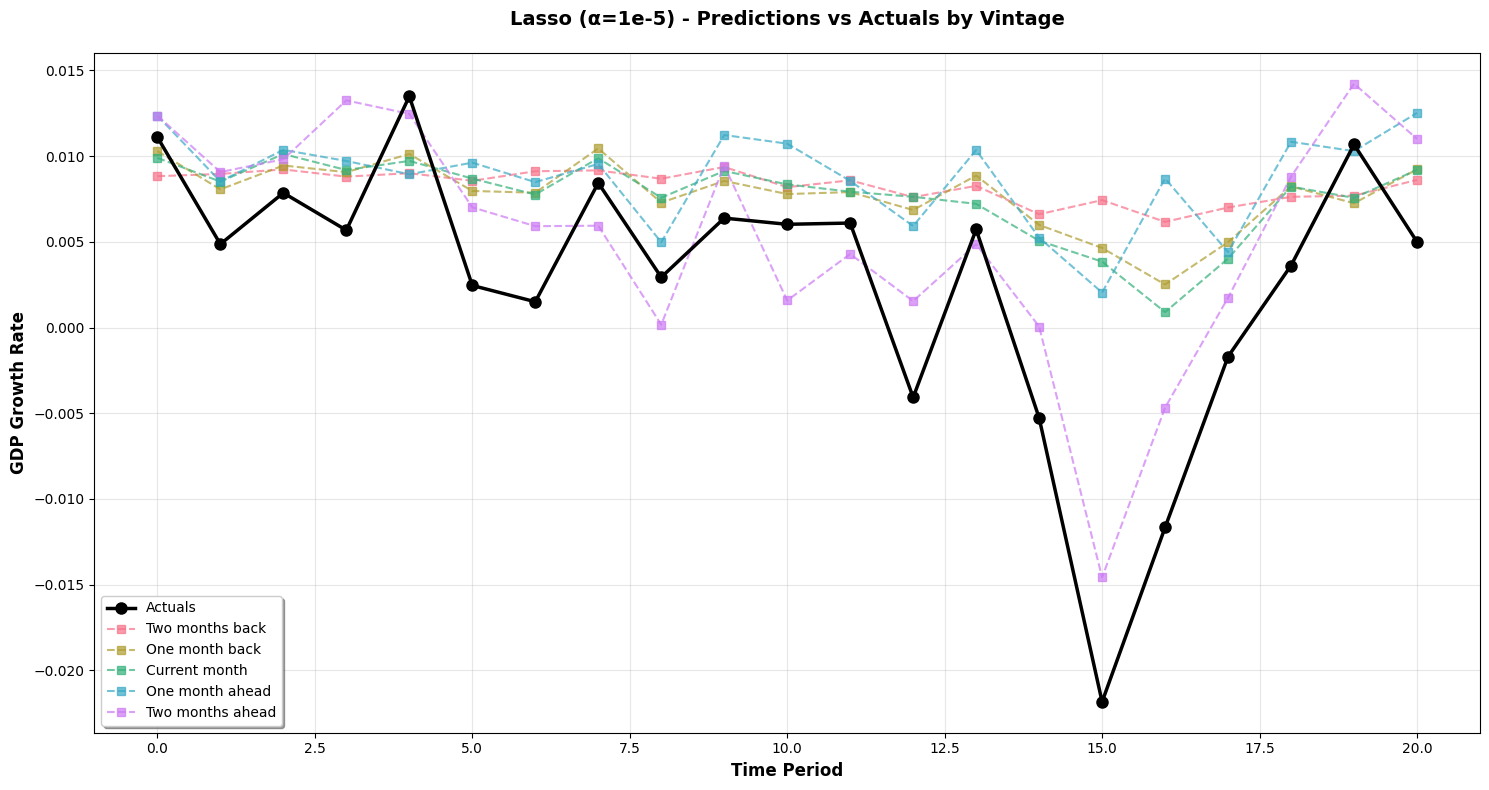

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Lasso (α=1e-5)')
plt.show()

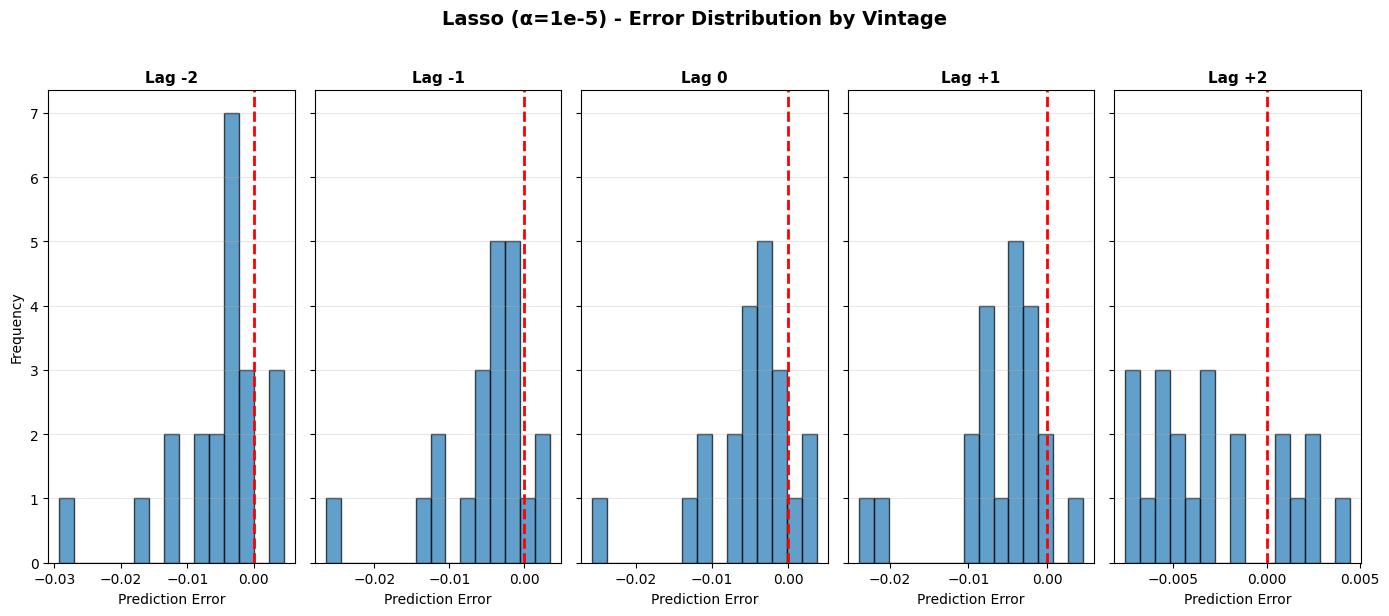

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Lasso (α=1e-5)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(lasso_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.007962977998638727
target_variable     : gdpc1
n_models            : 1
model_class         : Lasso


## Summary

This notebook implements Lasso regression for GDP nowcasting. Lasso uses L1 regularization, which encourages sparse solutions by driving some coefficients exactly to zero. This automatic feature selection can be particularly useful when working with many potential predictors.

The very small alpha value (1e-5) applies light regularization, allowing most features to remain in the model while still providing some protection against overfitting. The framework handles the backtesting complexity, letting us focus on model configuration and interpretation.